# Stochastic Gradient Descent

## Concept Explanation
Stochastic Gradient Descent (SGD) updates the model parameters frequently. Instead of computing the gradients over the entire dataset, it picks one single sample (or a shuffled sequence of single samples) and updates the weights and biases immediately.

**Formula (for a single instance $i$):**
$$dw = -2 \cdot x_i \cdot (y_i - \hat{y}_i)$$
$$db = -2 \cdot (y_i - \hat{y}_i)$$

## Expected Outcome
Because we update the parameters for *every single data point*, the path to convergence can be very noisy and chaotic. However, it takes far fewer epochs to reach a good model fit. We expect a jagged cost history curve but a highly capable optimized regression line.

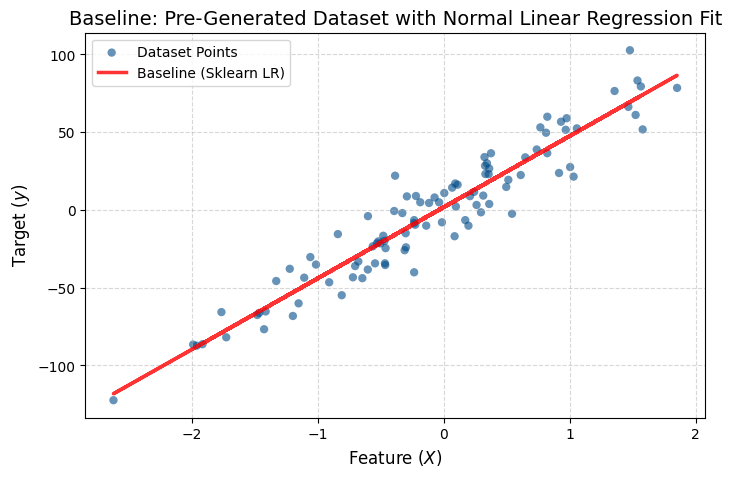

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# 1. Generate matching randomized dataset
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1) # Normalizing the output array dimensions

# 2. Fit Simple Linear Regression (Baseline) to check optimal path
lr = LinearRegression()
lr.fit(X, y)
y_lr_pred = lr.predict(X)

# 3. Data Scatter and Base Implementation Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='#004B87', alpha=0.6, edgecolors='none', label='Dataset Points')
plt.plot(X, y_lr_pred, color='red', linewidth=2.5, alpha=0.8, label='Baseline (Sklearn LR)')
plt.title('Baseline: Pre-Generated Dataset with Normal Linear Regression Fit', fontsize=14)
plt.xlabel('Feature ($X$)', fontsize=12)
plt.ylabel('Target ($y$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Stochastic Gradient Descent Implementation
With SGD, we update weights and bias for **every single data point**. To prevent cyclic behavior, it is usually a good idea to shuffle the data or step through instances randomly. We will use a standard loop. 

We will calculate and track the exact loss per epoch (average loss across all data points after updating). We predict the line fitting outcome below.

--- Stochastic Gradient Descent Metrics ---
Execution Time: 0.06148 seconds
Final Optimized Weight: 48.3805
Final Bias: -0.2586
MSE: 186.3013
MAE: 11.0713
R2 Score: 0.9013

--- Sklearn Baseline Metrics ---
MSE: 175.6221
MAE: 10.6567
R2 Score: 0.9069



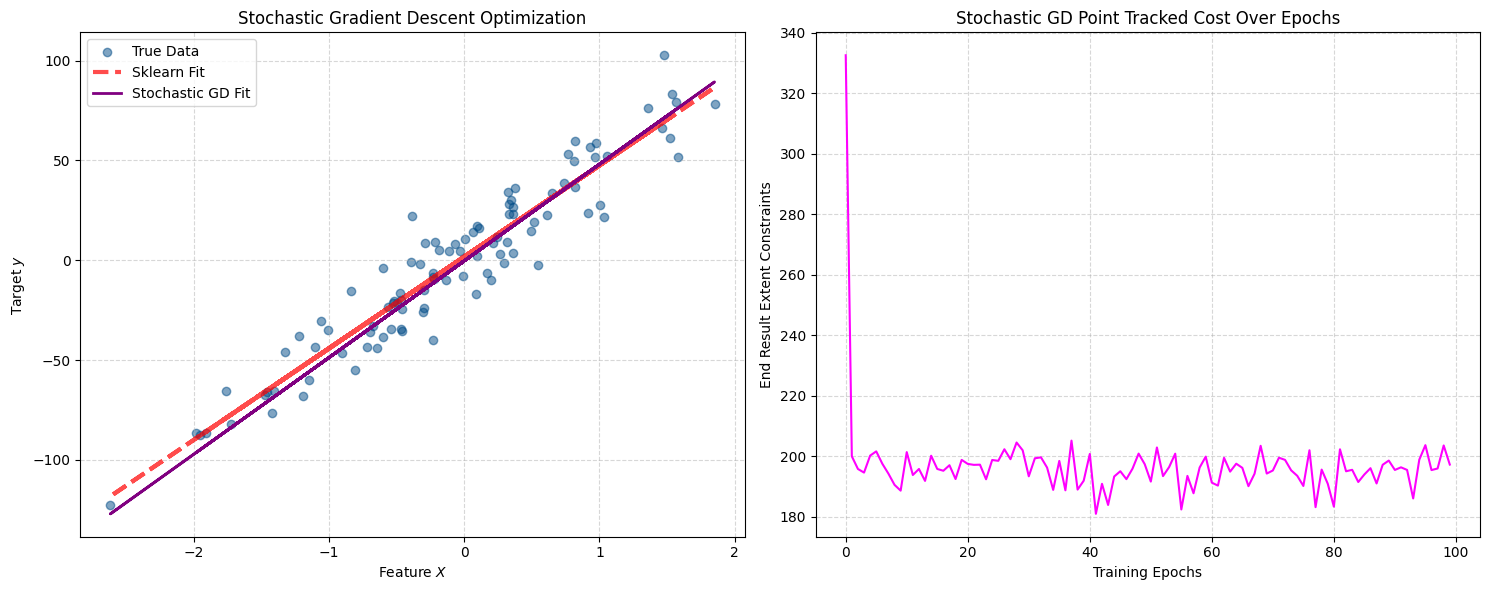

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

start_time = time.time()

# 1. Parameter Settings 
w = np.zeros((1, 1))
b = np.zeros((1, 1))

learning_rate = 0.05 
epochs = 100
n_total = len(X)
cost_history = [] 

for epoch in range(epochs):
    # To mimic SGD reliably, shuffle iterations inside the epoch sequence length limits
    permutation = np.random.permutation(n_total)
    X_shuffled = X[permutation]
    y_shuffled = y[permutation]
    
    epoch_total_cost = 0
    
    # Isolate independent point tracking iteratively down line arrays
    for i in range(n_total):
        X_iter = X_shuffled[i : i+1]
        y_iter = y_shuffled[i : i+1]
        
        y_pred_iter = X_iter.dot(w) + b
        
        dw = -2 * float(X_iter[0][0]) * float(y_iter[0][0] - y_pred_iter[0][0])
        db = -2 * float(y_iter[0][0] - y_pred_iter[0][0])
        
        # Modulates parameters single index matching constraints
        w -= learning_rate * dw
        b -= learning_rate * db
        
        epoch_total_cost += float(y_iter[0][0] - y_pred_iter[0][0])**2
        
    cost_history.append(epoch_total_cost / n_total) 

end_time = time.time()
execution_time = end_time - start_time

final_sgd_pred = X.dot(w) + b

print(f"--- Stochastic Gradient Descent Metrics ---")
print(f"Execution Time: {execution_time:.5f} seconds")
print(f"Final Optimized Weight: {float(w[0][0]):.4f}")
print(f"Final Bias: {float(b[0][0]):.4f}")
print(f"MSE: {mean_squared_error(y, final_sgd_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, final_sgd_pred):.4f}")
print(f"R2 Score: {r2_score(y, final_sgd_pred):.4f}\n")

print(f"--- Sklearn Baseline Metrics ---")
print(f"MSE: {mean_squared_error(y, y_lr_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, y_lr_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_lr_pred):.4f}\n")


# 3. Output Plot Details Render Path Limits
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].scatter(X, y, color='#004B87', alpha=0.5, label='True Data')
ax[0].plot(X, y_lr_pred, color='red', linestyle='--', linewidth=3, alpha=0.7, label='Sklearn Fit')
ax[0].plot(X, final_sgd_pred, color='purple', linewidth=2, label='Stochastic GD Fit')
ax[0].set_title('Stochastic Gradient Descent Optimization')
ax[0].set_xlabel('Feature $X$')
ax[0].set_ylabel('Target $y$')
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[1].plot(range(epochs), cost_history, color='magenta', linewidth=1.5)
ax[1].set_title('Stochastic GD Point Tracked Cost Over Epochs')
ax[1].set_xlabel('Training Epochs')
ax[1].set_ylabel('End Result Extent Constraints')
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()